In [6]:
# Importing Libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report


# feature selection
from sklearn.feature_selection import SelectKBest,f_classif

#Ensemble

from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV




In [7]:
# 2) Load Dataset

digits=load_digits()
x=pd.DataFrame(digits.data)
y=pd.Series(digits.target)


In [9]:
# Basic checks

print("Shape of x:",x.shape)
print("number of classes: ",y.nunique())
print("\n class distribution:/n", y.value_counts().sort_index())
print("/n missing values in x:",x.isnull().sum().sum())

Shape of x: (1797, 64)
number of classes:  10

 class distribution:/n 0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64
/n missing values in x: 0


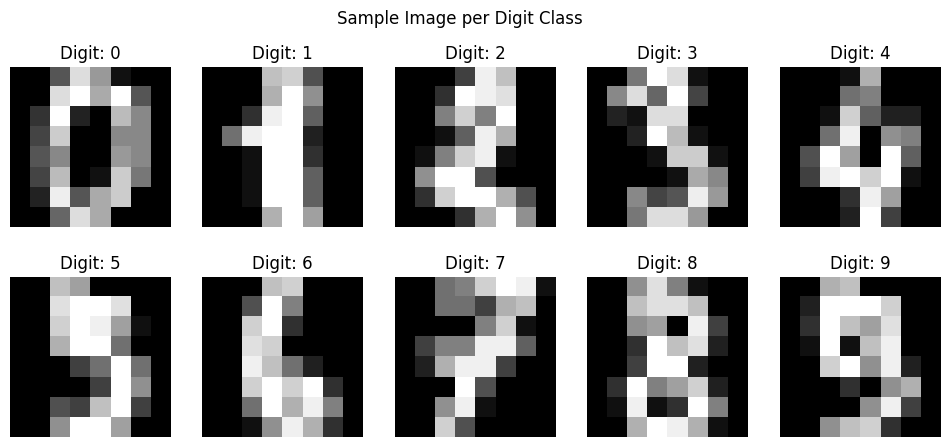

In [12]:
# Display 10 sample images (one per class)
plt.figure(figsize=(12, 5))

for digit_class in range(10):
    index = np.where(y == digit_class)[0][0]
    image = digits.images[index]

    plt.subplot(2, 5, digit_class + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Digit: {digit_class}")
    plt.axis('off')

plt.suptitle("Sample Image per Digit Class")
plt.show()


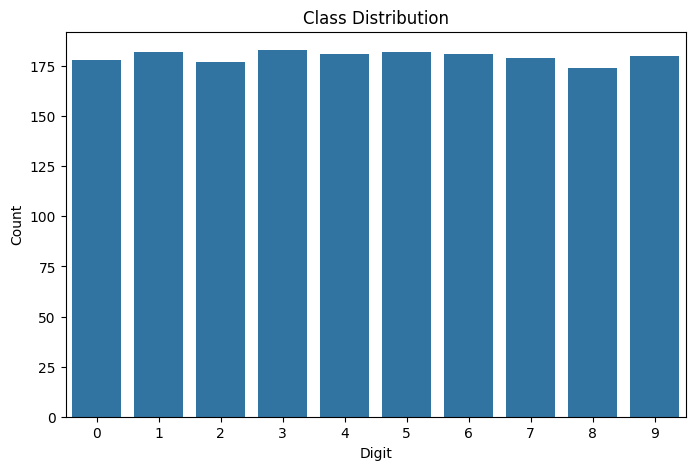

In [14]:
# Class Distribution Bar chart
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()


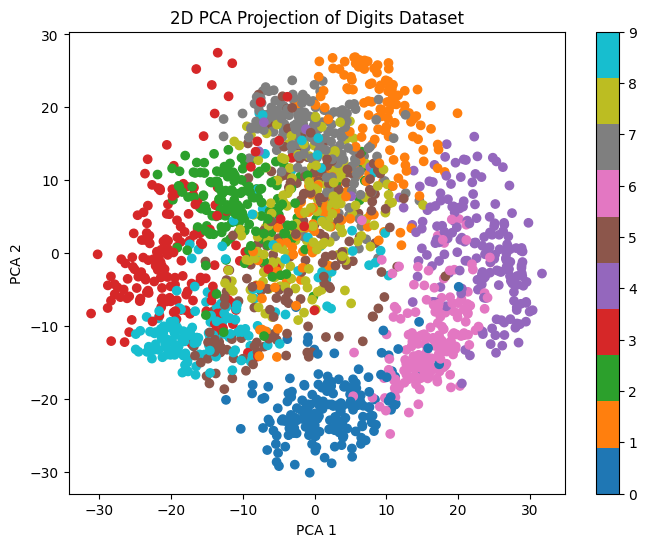

In [16]:
# PCA 2D Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10')
plt.colorbar(scatter)
plt.title("2D PCA Projection of Digits Dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()





In [18]:
#Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [21]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:
# Baseline Models
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision (Macro):", precision_score(y_test, y_pred, average='macro'))
    print("Recall (Macro):", recall_score(y_test, y_pred, average='macro'))
    print("F1 Score (Macro):", f1_score(y_test, y_pred, average='macro'))

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    print("="*60)


In [26]:
# Logistic Regression
lr = LogisticRegression(max_iter=500)

evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test)


Accuracy: 0.9722222222222222
Precision (Macro): 0.9721260358102464
Recall (Macro): 0.9719047619047618
F1 Score (Macro): 0.9719402197048348

Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 32  0  1  1  0  0  0  2  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  4  0  0  0  0  0  0 31  0]
 [ 0  0  0  0  0  0  0  0  1 35]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        3

In [27]:
# KNN
knn=KNeighborsClassifier()

evaluate_model(knn, X_train_scaled, X_test_scaled, y_train, y_test)

Accuracy: 0.9638888888888889
Precision (Macro): 0.9645896987673304
Recall (Macro): 0.9637215787215787
F1 Score (Macro): 0.9634399725952825

Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  1 36  0  0  0  0  0  0]
 [ 0  0  0  0 34  0  0  2  0  0]
 [ 0  0  0  0  0 36  0  0  0  1]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  1  0 35  0  0]
 [ 0  3  1  0  0  0  0  0 31  0]
 [ 0  0  0  0  1  0  1  1  1 32]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        3

In [30]:
#Decision Tree
dt=DecisionTreeClassifier()

evaluate_model(dt, X_train_scaled, X_test_scaled, y_train, y_test)

Accuracy: 0.8222222222222222
Precision (Macro): 0.8235597184483554
Recall (Macro): 0.8214693264693265
F1 Score (Macro): 0.8200993504259758

Confusion Matrix:
 [[34  0  0  0  0  0  0  1  1  0]
 [ 0 25  5  2  1  1  0  0  1  1]
 [ 0  0 29  3  0  0  0  0  2  1]
 [ 0  0  2 30  0  1  0  1  1  2]
 [ 1  1  1  0 31  0  0  0  2  0]
 [ 0  0  0  0  1 35  0  0  0  1]
 [ 0  2  1  0  1  2 30  0  0  0]
 [ 0  0  1  0  0  0  0 34  0  1]
 [ 0  4  0  2  0  1  2  2 23  1]
 [ 1  0  1  2  0  3  0  3  1 25]]

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        36
           1       0.78      0.69      0.74        36
           2       0.72      0.83      0.77        35
           3       0.77      0.81      0.79        37
           4       0.91      0.86      0.89        36
           5       0.81      0.95      0.88        37
           6       0.94      0.83      0.88        36
           7       0.83      0.94      0.88        3

Feature Selection + GridSearch
StandardScaler → SelectKBest → Classifier


In [32]:
# Logistic Regression + Grid Search

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('fs', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(max_iter=500))
])

param_grid = {
    'fs__k': [10, 20, 30, 40, 50, 64],
    'clf__C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

evaluate_model(best_model, X_train, X_test, y_train, y_test)



Best Parameters: {'clf__C': 1, 'fs__k': 64}
Best CV Score: 0.969954798748019
Accuracy: 0.9722222222222222
Precision (Macro): 0.9721260358102464
Recall (Macro): 0.9719047619047618
F1 Score (Macro): 0.9719402197048348

Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 32  0  1  1  0  0  0  2  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  4  0  0  0  0  0  0 31  0]
 [ 0  0  0  0  0  0  0  0  1 35]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      

In [33]:
#Bagging + GridSearch
pipeline_bag = Pipeline([
    ('fs', SelectKBest(score_func=f_classif)),
    ('clf', BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

param_grid_bag = {
    'fs__k': [20, 40, 64],
    'clf__n_estimators': [10, 50, 100],
    'clf__estimator__max_depth': [None, 5, 10]
}

grid_bag = GridSearchCV(
    pipeline_bag,
    param_grid_bag,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_bag.fit(X_train, y_train)

print("Best Bagging Params:", grid_bag.best_params_)
evaluate_model(grid_bag.best_estimator_, X_train, X_test, y_train, y_test)


Best Bagging Params: {'clf__estimator__max_depth': 10, 'clf__n_estimators': 100, 'fs__k': 64}
Accuracy: 0.9222222222222223
Precision (Macro): 0.9224387939536086
Recall (Macro): 0.9212655512655512
F1 Score (Macro): 0.9202600500046108

Confusion Matrix:
 [[34  0  0  0  1  0  0  0  1  0]
 [ 0 33  0  2  0  0  0  0  0  1]
 [ 1  0 33  0  0  0  0  0  1  0]
 [ 0  0  0 36  0  0  0  0  0  1]
 [ 1  1  0  0 34  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  1  0 34  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  2  0  1  0  4 24  1]
 [ 0  0  0  1  1  0  0  1  2 31]]

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        36
           1       0.89      0.92      0.90        36
           2       1.00      0.94      0.97        35
           3       0.88      0.97      0.92        37
           4       0.92      0.94      0.93        36
           5       0.97      1.00      0.99        37
           6

In [34]:
# Boosting.......AdaBoost
pipeline_ada = Pipeline([
    ('fs', SelectKBest(score_func=f_classif)),
    ('clf', AdaBoostClassifier(random_state=42))
])

param_grid_ada = {
    'fs__k': [20, 40, 64],
    'clf__n_estimators': [50, 100, 200],
    'clf__learning_rate': [0.01, 0.1, 1]
}

grid_ada = GridSearchCV(
    pipeline_ada,
    param_grid_ada,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

print("Best AdaBoost Params:", grid_ada.best_params_)
evaluate_model(grid_ada.best_estimator_, X_train, X_test, y_train, y_test)


Best AdaBoost Params: {'clf__learning_rate': 1, 'clf__n_estimators': 200, 'fs__k': 64}
Accuracy: 0.8638888888888889
Precision (Macro): 0.8739352303607522
Recall (Macro): 0.8634663234663235
F1 Score (Macro): 0.8652072818503133

Confusion Matrix:
 [[34  0  0  0  0  0  0  0  2  0]
 [ 0 26  1  0  3  0  0  1  2  3]
 [ 0  0 28  0  0  0  0  0  7  0]
 [ 0  0  2 32  0  1  0  0  0  2]
 [ 1  4  0  0 29  0  0  2  0  0]
 [ 0  0  0  0  1 36  0  0  0  0]
 [ 1  3  0  0  0  0 30  0  2  0]
 [ 0  0  0  1  0  0  0 34  1  0]
 [ 1  2  0  0  0  0  0  1 31  0]
 [ 0  0  0  0  1  0  0  1  3 31]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        36
           1       0.74      0.72      0.73        36
           2       0.90      0.80      0.85        35
           3       0.97      0.86      0.91        37
           4       0.85      0.81      0.83        36
           5       0.97      0.97      0.97        37
           6       

In [35]:
#Gradient Boosting
pipeline_gb = Pipeline([
    ('fs', SelectKBest(score_func=f_classif)),
    ('clf', GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    'fs__k': [20, 40, 64],
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    pipeline_gb,
    param_grid_gb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best GB Params:", grid_gb.best_params_)
evaluate_model(grid_gb.best_estimator_, X_train, X_test, y_train, y_test)


Best GB Params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'fs__k': 40}
Accuracy: 0.9527777777777777
Precision (Macro): 0.9530579501245136
Recall (Macro): 0.9523809523809523
F1 Score (Macro): 0.9520836547430849

Confusion Matrix:
 [[35  0  0  0  0  0  0  0  1  0]
 [ 1 30  0  2  0  1  1  0  0  1]
 [ 1  0 34  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 34  0  2  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  1 31  0]
 [ 0  0  0  1  0  0  0  2  0 33]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        36
           1       0.91      0.83      0.87        36
           2       1.00      0.97      0.99        35
           3       0.93      1.00      0.96        37
           4       1.00      1.00      1.00        36
           5       0.97      1.00      0.99        37
  

In [ ]:
#Stacking + Feature Selection
base_models = [
    ('lr', LogisticRegression(max_iter=500)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)

pipeline_stack = Pipeline([
    ('scaler', StandardScaler()),
    ('fs', SelectKBest(score_func=f_classif, k=40)),
    ('clf', stack)
])

pipeline_stack.fit(X_train, y_train)

evaluate_model(pipeline_stack, X_train, X_test, y_train, y_test)



**The End**